# A2 — Pierce 1890 Knowledge-Base Demo
**Team G07 · doc-agent · Assignment 2**

This notebook provides graded A2 evidence:
1. **Part 1** — OCR quality metrics (CER, WER, Word-F1) on the 24 held-out pages vs. `grading_kit/labels.jsonl`
2. **Part 2** — Index overview (chunk count, dimension, pages indexed)
3. **Part 3** — Live vector retrieval demo with page citations and rendered figure images

> Run cells top to bottom after `bash scripts/build_index.sh` has completed.

In [7]:
import sys, json, re, html
from collections import Counter
from pathlib import Path

import yaml
import numpy as np

# Auto-detect repository root whether kernel started in . or ./notebooks
cwd = Path.cwd().resolve()
REPO = cwd.parent if not (cwd / 'configs' / 'config.yaml').is_file() and (cwd.parent / 'configs' / 'config.yaml').is_file() else cwd
sys.path.insert(0, str(REPO / 'src'))

cfg = yaml.safe_load((REPO / 'configs' / 'config.yaml').read_text())
INDEX_DIR     = (REPO / Path(cfg['index']['path'])).resolve()
cfg['index']['path'] = str(INDEX_DIR)  # Ensure absolute path for store.py

LABELS_PATH   = (REPO / 'grading_kit' / 'labels.jsonl').resolve()
CHANDRA_DIR   = (REPO / 'chandra').resolve()
PAGES_MD      = (REPO / 'chandra' / 'pages.md').resolve()
IMG_IDX_PATH  = INDEX_DIR / 'image_index.json'

print('REPO root :', REPO)
print('Labels    :', LABELS_PATH.is_file(), f'({LABELS_PATH})')
print('Index dir :', INDEX_DIR.is_dir(), f'({INDEX_DIR})')


REPO root : /Users/mehemudazad/Desktop/DL_project/doc-agent-7
Labels    : True (/Users/mehemudazad/Desktop/DL_project/doc-agent-7/grading_kit/labels.jsonl)
Index dir : True (/Users/mehemudazad/Desktop/DL_project/doc-agent-7/data/processed/index)


## Part 1 — OCR Quality on Held-Out Pages

In [8]:
if not LABELS_PATH.is_file():
    raise FileNotFoundError(f'Missing {LABELS_PATH} — add hand-corrected labels.')

labels = {}
for line in LABELS_PATH.read_text('utf-8').splitlines():
    if not line.strip() or line.lstrip().startswith('#'):
        continue
    row = json.loads(line)
    labels[row['page_id']] = row['text']

print(f'Loaded {len(labels)} held-out labels: {sorted(labels.keys())[:5]} ...')


Loaded 24 held-out labels: ['p0024', 'p0025', 'p0026', 'p0027', 'p0028'] ...


In [9]:
# Parse chandra/pages.md and extract clean text per page
from doc_agent.index.chunk import load_from_pages_markdown

page_chunks, image_index = load_from_pages_markdown(PAGES_MD, cfg['ingest']['doc_id'])
chandra_text = {c.page_ids[0]: c.text for c in page_chunks}
print(f'Total pages indexed: {len(chandra_text)}')

# ─── Metric helpers ───────────────────────────────────────────────────────────
def normalize(t): return re.sub(r'\s+', ' ', t).strip().lower()

def levenshtein(a, b):
    if len(a) < len(b): a, b = b, a
    prev = list(range(len(b)+1))
    for i, av in enumerate(a, 1):
        cur = [i]
        for j, bv in enumerate(b, 1):
            cur.append(min(prev[j]+1, cur[-1]+1, prev[j-1]+(av!=bv)))
        prev = cur
    return prev[-1]

def word_f1(hyp, ref):
    h, r = Counter(normalize(hyp).split()), Counter(normalize(ref).split())
    tp = sum((h & r).values())
    if not h and not r: return 1.0
    if not tp: return 0.0
    p, rc = tp/sum(h.values()), tp/sum(r.values())
    return 2*p*rc/(p+rc)

# ─── Score each held-out page ────────────────────────────────────────────────
results = []
for pid, ref in sorted(labels.items()):
    hyp  = chandra_text.get(pid, '')
    ref_n, hyp_n = normalize(ref), normalize(hyp)
    cer = levenshtein(list(hyp_n), list(ref_n)) / max(len(ref_n), 1)
    wer = levenshtein(hyp_n.split(), ref_n.split()) / max(len(ref_n.split()), 1)
    f1  = word_f1(hyp, ref)
    results.append({'page_id': pid, 'cer': cer, 'wer': wer, 'word_f1': f1})

macro_f1 = sum(r['word_f1'] for r in results) / max(len(results), 1)
micro_cer = sum(r['cer'] for r in results) / max(len(results), 1)
micro_wer = sum(r['wer'] for r in results) / max(len(results), 1)

print(f'\n{"Page":<10} {"CER":>7} {"WER":>7} {"Word F1":>9}')
print('-' * 38)
for r in results:
    print(f"{r['page_id']:<10} {r['cer']:>7.4f} {r['wer']:>7.4f} {r['word_f1']:>9.4f}")
print('-' * 38)
print(f'  MACRO AVG  {micro_cer:>7.4f} {micro_wer:>7.4f} {macro_f1:>9.4f}')
print(f'\nSample size: {len(results)} held-out pages')


Total pages indexed: 1028

Page           CER     WER   Word F1
--------------------------------------
p0024       0.3279  0.3786    0.8080
p0025       0.0323  0.0894    0.9322
p0026       0.0207  0.0363    0.9711
p0027       0.4958  0.5252    0.8339
p0028       0.4735  0.4855    0.7825
p0029       1.0160  1.0311    0.6740
p0030       0.3880  0.5077    0.8208
p0031       0.4951  0.5914    0.8231
p0032       0.5091  0.6491    0.7226
p0033       0.3788  0.4025    0.8802
p0034       0.7613  0.7732    0.8519
p0035       0.0280  0.0568    0.9502
p0036       0.5359  0.5772    0.7617
p0037       0.0216  0.0466    0.9608
p0038       0.2757  0.2795    0.8571
p0039       0.4269  0.4209    0.8516
p0040       0.6106  0.6939    0.7667
p0041       4.8000  4.3333    0.3036
p0042       0.0160  0.0172    0.9888
p0043       6.1415  5.3333    0.2462
p0044       0.0331  0.0307    0.9844
p0045       0.5889  0.6933    0.7845
p0046       0.4504  0.5182    0.8462
p0047       0.3240  0.3333    0.8560
---------

## Part 2 — Index Overview

In [10]:
from doc_agent.index.store import load

faiss_index, indexed_chunks, metadata = load(cfg)

# Load image index
img_idx = json.loads(IMG_IDX_PATH.read_text()) if IMG_IDX_PATH.exists() else {}
pages_with_figs = len(img_idx)
total_figs      = sum(len(v) for v in img_idx.values())

print('=' * 55)
print('  STAGE 4 — FAISS KNOWLEDGE BASE STATISTICS')
print('=' * 55)
print(f'  Index type         : {metadata["index_type"]}')
print(f'  Embedding model    : {cfg["embed"]["model"]}')
print(f'  Embedding dim      : {metadata["dimension"]}')
print(f'  Total chunks       : {metadata["count"]}')
print(f'  Chunk size (tokens): {cfg["index"]["chunk_tokens"]} (overlap {cfg["index"]["overlap"]})')
print(f'  Pages indexed      : {len(set(pid for c in indexed_chunks for pid in c.page_ids))}')
print(f'  Pages with figures : {pages_with_figs}  ({total_figs} total figure refs)')
print(f'  Index vectors      : {faiss_index.ntotal}')
print('=' * 55)


  STAGE 4 — FAISS KNOWLEDGE BASE STATISTICS
  Index type         : faiss:flat_ip
  Embedding model    : sentence-transformers/all-MiniLM-L6-v2
  Embedding dim      : 384
  Total chunks       : 2088
  Chunk size (tokens): 256 (overlap 32)
  Pages indexed      : 1028
  Pages with figures : 252  (350 total figure refs)
  Index vectors      : 2088


## Part 3 — Live Vector Retrieval Demo

/Users/mehemudazad/Desktop/DL_project/doc-agent-7/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/mehemudazad/Desktop/DL_project/doc-agent-7/.venv/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


### Query: *What are the superficial muscles of the chest and abdomen?*

**Result 1** | Page: `p0041` | Cosine score: `0.6792`

> *Fig. 24.*Anatomical illustration of the superficial muscles of the anterior human body.A detailed black and white anatomical engraving of a human male figure from the front, showing the superficial layer of muscles. The muscles are meticulously rendered with fine lines and shading to show their complex arrangement, including the facial muscles, pectoralis major, abdominal muscles, and the various...

  📷 Anatomical illustration of the superficial muscles of the anterior human body.


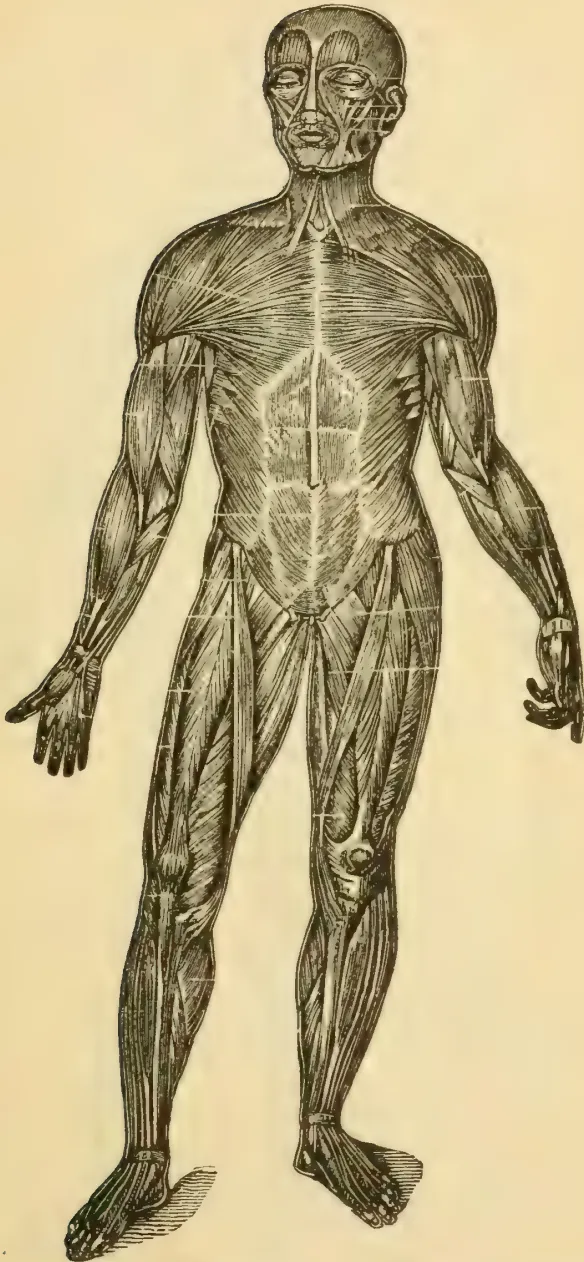

**Result 2** | Page: `p0043` | Cosine score: `0.6204`

> *Fig. 25.*Anatomical illustration of the posterior muscles of the human body.A detailed black and white anatomical engraving of a human figure from the posterior view. The figure is standing with arms slightly abducted and palms facing forward. The illustration meticulously depicts the superficial layer of muscles across the entire back, including the trapezius, latissimus dorsi, and erector spina...

  📷 Anatomical illustration of the posterior muscles of the human body.


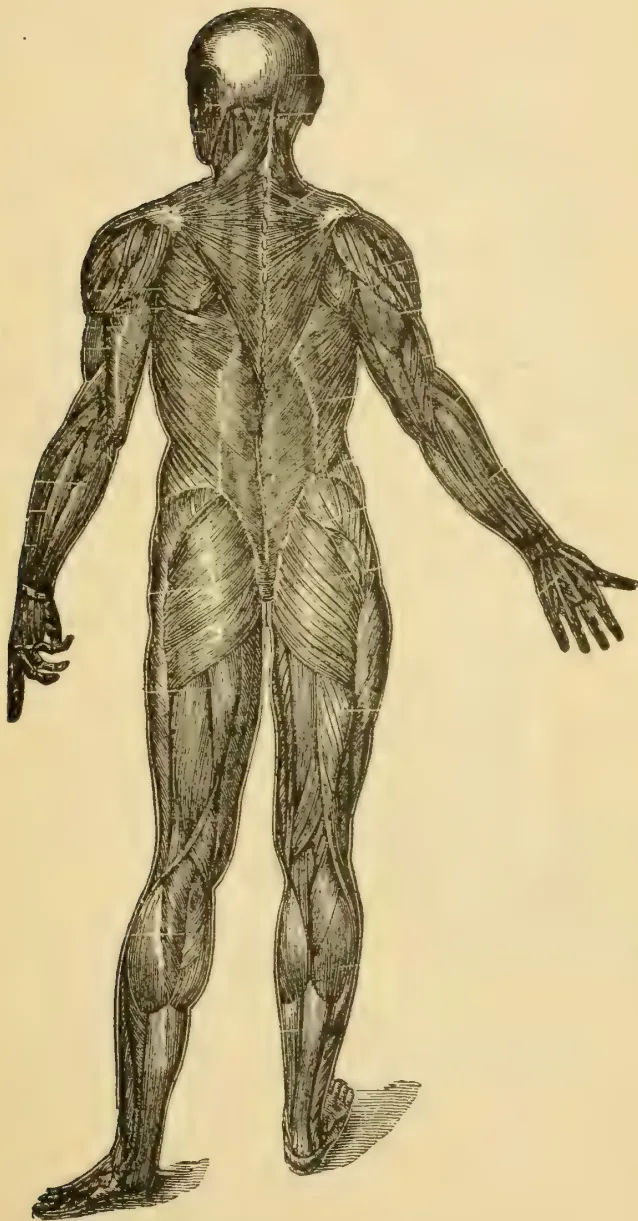

**Result 3** | Page: `p0040` | Cosine score: `0.5617`

> employed in respiration are of this class, for we can breathe rapidly or slowly, and, for a short time, even suspend their action; but soon, however, the organic muscles assert their instinctive control, and respiration is resumed. **The Diaphragm,** or midriff, is the muscular division between the thorax and the abdomen. It has been compared to an inverted basin, the concavity of which is Fig. 23...

  📷 Figure 22: Two diagrams of an unstriated muscular fiber. The left diagram, labeled 'b', shows the fi


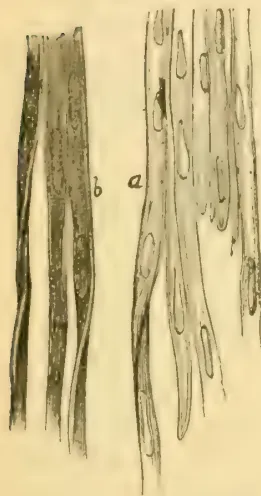

  📷 Figure 23: A detailed anatomical illustration of the underside of the human diaphragm. The drawing s


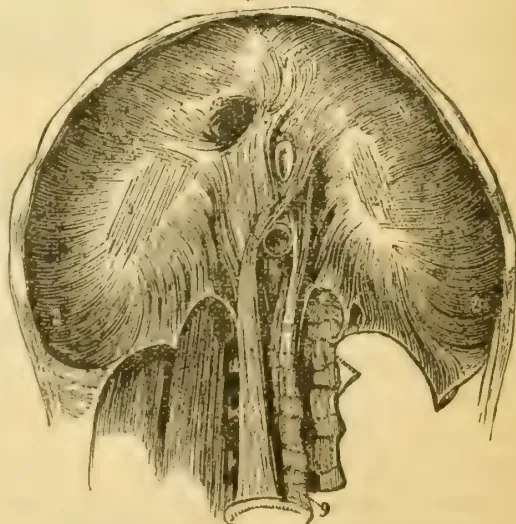

In [11]:
from sentence_transformers import SentenceTransformer
import faiss
from IPython.display import display, Image as IPImage, Markdown

embedder = SentenceTransformer(cfg['embed']['model'])

def retrieve(query: str, k: int = 5):
    """Embed query, search index, return top-k (chunk, score, images) tuples."""
    qvec = embedder.encode([query], normalize_embeddings=True).astype('float32')
    scores, positions = faiss_index.search(qvec, k)
    hits = []
    for score, pos in zip(scores[0], positions[0]):
        if pos < 0: continue
        chunk = indexed_chunks[pos]
        page_id = chunk.page_ids[0]
        page_imgs = img_idx.get(page_id, [])
        hits.append({'chunk': chunk, 'score': float(score), 'images': page_imgs})
    return hits

def show_results(query: str, k: int = 3):
    display(Markdown(f'### Query: *{query}*'))
    hits = retrieve(query, k)
    for i, h in enumerate(hits, 1):
        c = h['chunk']
        display(Markdown(
            f'**Result {i}** | Page: `{c.page_ids[0]}` | Cosine score: `{h["score"]:.4f}`\n\n'
            f'> {c.text[:400]}...'
        ))
        for img_meta in h['images'][:2]:  # show up to 2 figures per page
            img_path = CHANDRA_DIR / img_meta['webp']
            if img_path.exists():
                print(f'  📷 {img_meta["caption"][:100]}')
                display(IPImage(str(img_path), width=450))
        print()

# ─── Demo queries ──────────────────────────────────────────────────────────
show_results('What are the superficial muscles of the chest and abdomen?')


In [12]:
show_results('What remedies are prescribed for inflammation and fever?')


### Query: *What remedies are prescribed for inflammation and fever?*

**Result 1** | Page: `p0409` | Cosine score: `0.5634`

> GENERAL PRINCIPLES FOR TREATMENT OF INFLAMMATION. Remove the exciting causes as far as practicable. If caused by a splinter or any foreign substance, it should be withdrawn, and if the injury is merely local, apply cold water to the parts to subdue the inflammation. If caused by a rabid animal, the wound should be enlarged and cupped, and the parts cleansed or destroyed by caustic. The patient sho...

**Result 2** | Page: `p0406` | Cosine score: `0.5399`

> more painful than is natural. Inflammation is limited to certain parts, while fever influences the system generally. Inflammation gives rise to new formations, morbid products, and lesions, or alterations of structure. The morbid products of fever, and its modification of fluids are carried away by the secretions and excretions. The susceptibility of the body to inflammation may be *natural* or *a...

**Result 3** | Page: `p0412` | Cosine score: `0.5341`

> Drinking freely of pleurisy-root tea, or of a strong decoction of boneset is frequently useful. After free sweating has been established, then it is proper to follow by the use of diuretic teas, such as that of spearmint and pumpkin seed combined, or sweet spirits of nitre, in doses of twenty to thirty drops, added to a teaspoonful of the Extract of Smart-weed, diluted with sweetened water. To les...

### Query: *Describe the structure and function of the human heart.*

**Result 1** | Page: `p0065` | Cosine score: `0.6152`

> by a movable partition, the cavity above each transverse partition being called the *auricle*, and the cavity below, the *ventricle*, right or left, as the case may be. The walls of the auricles are much thinner than those of the ventricles, and the wall of the right ventricle is much thinner than that of the left, from the fact that the ventricles have more work to perform than the auricles, and ...

  📷 Anatomical illustration of the human heart and lungs, labeled Fig. 40. The trachea (t) is at the top


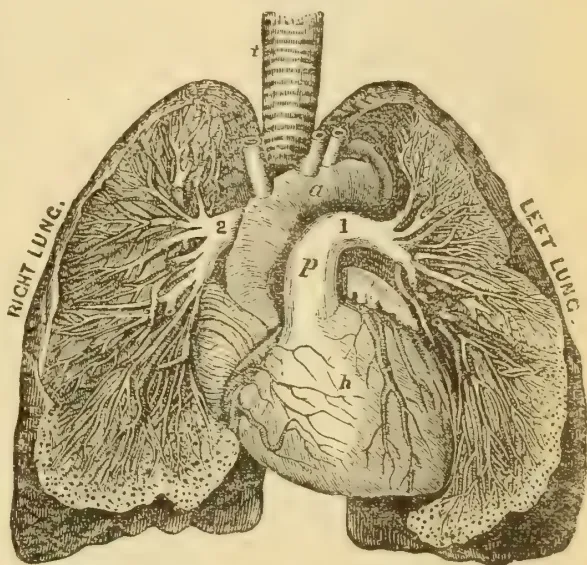

**Result 2** | Page: `p0064` | Cosine score: `0.6116`

> ## CHAPTER VII. --- # PHYSIOLOGICAL ANATOMY. --- ### CIRCULATORY ORGANS. Having considered the formation of chyle, traced it through the digestive process, seen its transmission into the *vena cava*, and, finally, its conversion into blood, we shall now describe how it is distributed to every part of the system. This is accomplished through organs which, from the round of duties they perform, are ...

**Result 3** | Page: `p0378` | Cosine score: `0.5487`

> is a fundamental principle which underlies every vital process. Health consists in normal, functional activity. The human system is the arena of various kinds of motions, both of fluids and of solids, and life and health depend upon these physiological movements. There are the movements incident to *respiration*, the expansion and contraction of the walls of the chest, bringing the oxygen of the a...

In [13]:
show_results('Describe the structure and function of the human heart.')


## A2 Form — Numbers to Copy
Copy the values from the cells above directly into **Section 5** of `forms/A2_form.docx`.

| Metric | Value |
|---|---|
| OCR sample size | *from Part 1 output* |
| Macro Word-F1 | *from Part 1 output* |
| Micro CER | *from Part 1 output* |
| Chunks indexed | *from Part 2 output* |
| Embedding dim | 384 (all-MiniLM-L6-v2) |
| Index type | faiss:flat_ip |
| Pages with figures | *from Part 2 output* |
| Query shown | *from Part 3 output* |
| Top-1 page citation | *from Part 3 output* |